# Exploratory Data Analysis

## Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

COLORS = {
    "red":      "#E10600",
    "charcoal": "#1F1F27",
    "slate":    "#5B5F66",
    "cream":    "#F7F4EF",
    "panel":    "#FFFFFF",
    "grid":     "#E4E0DA",
    "accent":   "#0090D4",
}
COMPOUND_COLORS = {
    "SOFT":         "#DA291C",
    "MEDIUM":       "#F5C518",
    "HARD":         "#B4B4B4",
    "INTERMEDIATE": "#43B02A",
    "WET":          "#0067AD",
}

sns.set_theme(style="white", context="notebook")
mpl.rcParams.update({
    "figure.facecolor":     COLORS["cream"],
    "axes.facecolor":       COLORS["panel"],
    "savefig.facecolor":    COLORS["cream"],
    "savefig.dpi":          150,
    "savefig.bbox":         "tight",
    "savefig.pad_inches":   0.35,
    "axes.edgecolor":       COLORS["slate"],
    "axes.linewidth":       0.8,
    "axes.labelcolor":      COLORS["charcoal"],
    "axes.titlecolor":      COLORS["charcoal"],
    "axes.titlesize":       16,
    "axes.titleweight":     "bold",
    "axes.titlelocation":   "left",
    "axes.titlepad":        38,
    "axes.labelsize":       11,
    "axes.labelweight":     "semibold",
    "axes.labelpad":        8,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "xtick.color":          COLORS["charcoal"],
    "ytick.color":          COLORS["charcoal"],
    "xtick.labelsize":      10,
    "ytick.labelsize":      10,
    "grid.color":           COLORS["grid"],
    "grid.linewidth":       0.8,
    "font.family":          "DejaVu Sans",
    "font.size":            11,
    "legend.frameon":       False,
})

def add_subtitle(ax, text):
    ax.text(0, 1.02, text, transform=ax.transAxes,
            ha="left", va="bottom",
            color=COLORS["slate"], fontsize=10.5)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR
for _ in range(4):
    if (PROJECT_ROOT / "data").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "f1_strategy_dataset_v4_validated.csv"
FIG_DIR   = PROJECT_ROOT / "reports" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "WillPitNextLap"
TARGET_PALETTE = {0: COLORS["charcoal"], 1: COLORS["red"]}


## 1. Load & Prepare the Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values:")
miss = df.isna().sum()
print(miss[miss > 0] if miss.sum() else "  (none)")
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print(f"Target used for EDA: {TARGET}")
print(df[TARGET].value_counts().rename_axis(TARGET).to_string())


Shape: (101371, 18)

Dtypes:
Driver                        str
LapNumber                   int64
Compound                      str
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
Race                          str
Year                        int64
LapTime_Delta             float64
Cumulative_Degradation    float64
PitStop                     int64
PitNextLap                  int64
RaceProgress              float64
Normalized_TyreLife       float64
Position_Change           float64
NextStint                 float64
WillPitNextLap              int64
dtype: object

Missing values:
Compound       66
NextStint    1848
dtype: int64

Duplicate rows: 0

Target used for EDA: WillPitNextLap
WillPitNextLap
0    98100
1     3271


## 2. Target Distribution

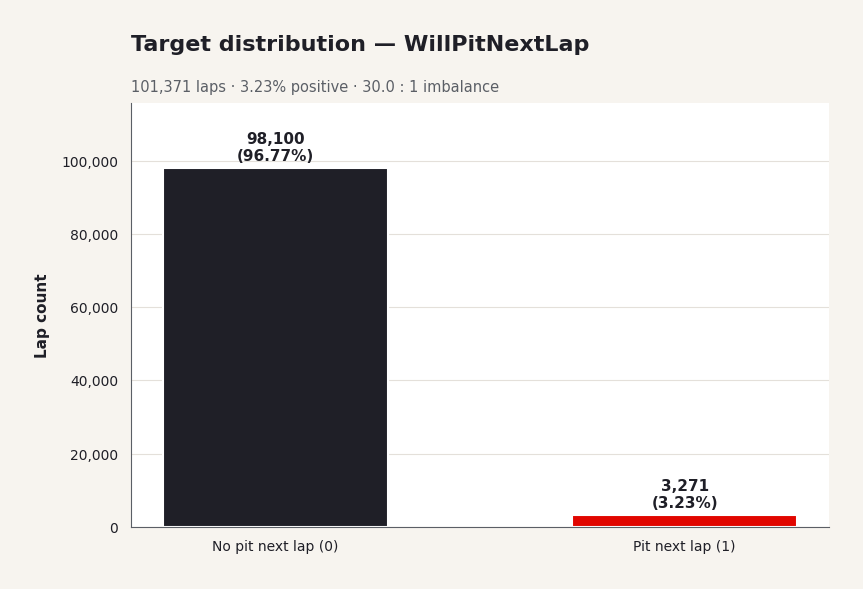

Insight: Only 3.23% of laps are positives (3,271 of 101,371), giving a 30.0:1 imbalance. Modelling will need stratified splits and non-accuracy metrics (PR-AUC, recall, F1) — accuracy would score ~96.8% just by predicting 'no pit' every lap.


In [3]:
counts = df[TARGET].value_counts().sort_index()
pos, neg = int(counts.get(1, 0)), int(counts.get(0, 0))
total    = pos + neg
pos_rate = pos / total
neg_rate = neg / total
imbalance = neg / pos if pos else float("inf")

fig, ax = plt.subplots(figsize=(9, 5.5))
labels = ["No pit next lap (0)", "Pit next lap (1)"]
bars = ax.bar(labels, [neg, pos],
              color=[COLORS["charcoal"], COLORS["red"]],
              width=0.55, edgecolor="white", linewidth=1.5)
for b, v, p in zip(bars, [neg, pos], [neg_rate, pos_rate]):
    ax.text(b.get_x() + b.get_width()/2, v + neg * 0.012,
            f"{v:,}\n({p:.2%})", ha="center", va="bottom",
            fontsize=11, fontweight="semibold", color=COLORS["charcoal"])

ax.set_title("Target distribution — WillPitNextLap")
add_subtitle(ax, f"{total:,} laps · {pos_rate:.2%} positive · {imbalance:.1f} : 1 imbalance")
ax.set_ylabel("Lap count")
ax.set_ylim(0, neg * 1.18)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "target_distribution.png"); plt.show()

print(f"Insight: Only {pos_rate:.2%} of laps are positives ({pos:,} of {total:,}), "
      f"giving a {imbalance:.1f}:1 imbalance. Modelling will need stratified splits and "
      f"non-accuracy metrics (PR-AUC, recall, F1) — accuracy would score ~{neg_rate:.1%} "
      f"just by predicting 'no pit' every lap.")


## 3. Tyre Life Analysis

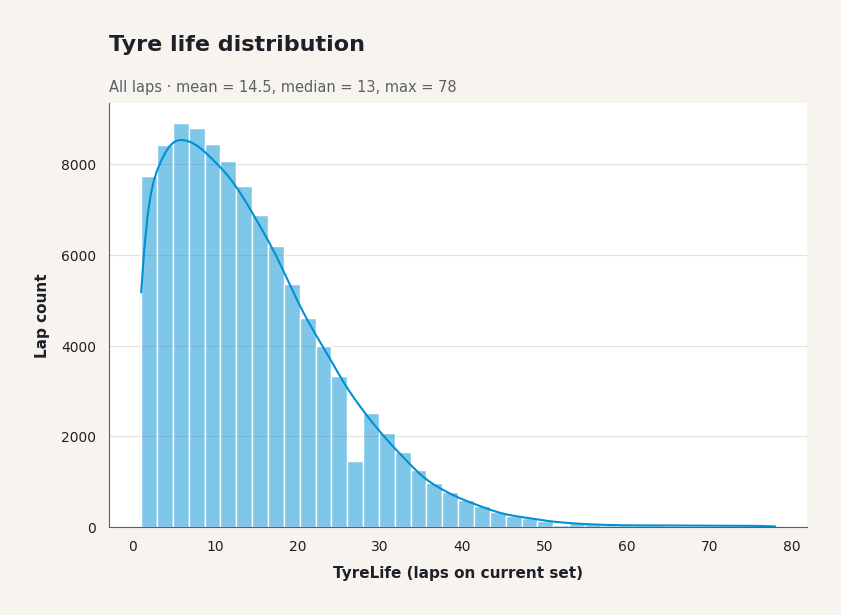

Insight: TyreLife is right-skewed — 75% of laps are on tyres with ≤20 laps of wear. The long tail (max 78 laps) is a small population of one-stop strategies; the model will see far fewer examples of very old tyres.


In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(df["TyreLife"], bins=40, kde=True,
             color=COLORS["accent"], edgecolor="white", ax=ax)
ax.set_title("Tyre life distribution")
add_subtitle(ax, f"All laps · mean = {df['TyreLife'].mean():.1f}, "
                 f"median = {df['TyreLife'].median():.0f}, max = {int(df['TyreLife'].max())}")
ax.set_xlabel("TyreLife (laps on current set)")
ax.set_ylabel("Lap count")
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "tyre_life_distribution.png"); plt.show()

share_under_20 = (df["TyreLife"] <= 20).mean()
print(f"Insight: TyreLife is right-skewed — {share_under_20:.0%} of laps are on tyres "
      f"with ≤20 laps of wear. The long tail (max {int(df['TyreLife'].max())} laps) is "
      f"a small population of one-stop strategies; the model will see far fewer examples of very old tyres.")


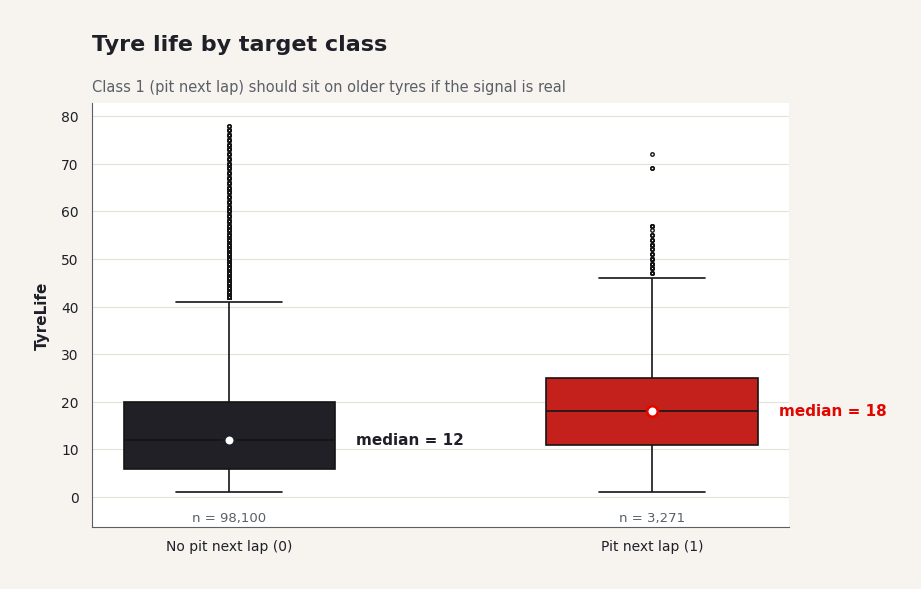

Insight: Median TyreLife is 12 laps for class 0 vs 18 laps for class 1 (Δ = 6 laps). The clear upward shift confirms tyre wear is one of the primary physical signals preceding a pit decision.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x=TARGET, y="TyreLife", hue=TARGET,
            palette=TARGET_PALETTE, legend=False,
            width=0.50, linewidth=1.2, fliersize=2.5, ax=ax)

medians = df.groupby(TARGET)["TyreLife"].median()
counts_ = df.groupby(TARGET).size()
ymax = df["TyreLife"].max()
for i, (med, n) in enumerate(zip(medians.values, counts_.values)):
    c = TARGET_PALETTE[i]
    ax.scatter([i], [med], s=60, color="white", edgecolor=c, linewidth=2.0, zorder=5)
    ax.text(i + 0.30, med, f"median = {int(med)}",
            va="center", ha="left", fontsize=11, fontweight="bold", color=c)
    ax.text(i, -ymax * 0.04, f"n = {int(n):,}",
            ha="center", va="top", fontsize=9.5, color=COLORS["slate"])

ax.set_title("Tyre life by target class")
add_subtitle(ax, "Class 1 (pit next lap) should sit on older tyres if the signal is real")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No pit next lap (0)", "Pit next lap (1)"])
ax.set_xlabel(""); ax.set_ylabel("TyreLife")
ax.set_ylim(-ymax * 0.08, ymax * 1.06)
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "tyre_life_by_target.png"); plt.show()

m0, m1 = int(medians.iloc[0]), int(medians.iloc[1])
print(f"Insight: Median TyreLife is {m0} laps for class 0 vs {m1} laps for class 1 "
      f"(Δ = {m1 - m0} laps). The clear upward shift confirms tyre wear is one of the "
      f"primary physical signals preceding a pit decision.")


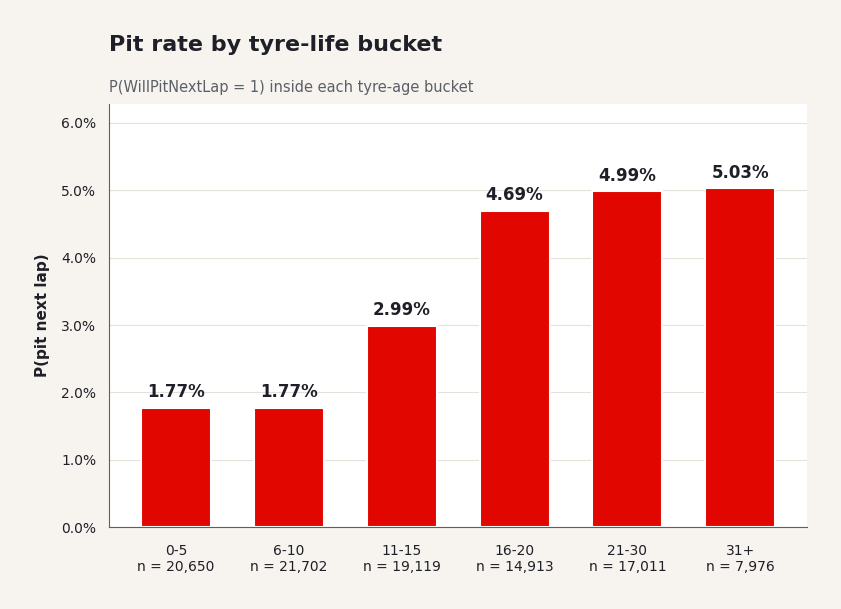

Insight: Pit rate rises with tyre age — from 1.77% on fresh tyres (0–5 laps) to 5.03% on very worn tyres (31+ laps). Tyre wear is monotonically informative and should be the single most useful feature for a classical model.


In [6]:
bins   = [0, 5, 10, 15, 20, 30, df["TyreLife"].max() + 1]
labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31+"]
buckets = pd.cut(df["TyreLife"], bins=bins, labels=labels,
                 right=True, include_lowest=True)
g = df.groupby(buckets, observed=True)[TARGET].agg(["mean", "count"])

xlabels = [f"{lab}\nn = {n:,}" for lab, n in zip(g.index.astype(str), g["count"].values)]
values  = g["mean"].values

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(range(len(g)), values, color=COLORS["red"],
              edgecolor="white", linewidth=1.5, width=0.62)
for i, v in enumerate(values):
    ax.text(i, v + values.max() * 0.02, f"{v:.2%}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=COLORS["charcoal"])

ax.set_title("Pit rate by tyre-life bucket")
add_subtitle(ax, "P(WillPitNextLap = 1) inside each tyre-age bucket")
ax.set_xticks(range(len(g))); ax.set_xticklabels(xlabels)
ax.set_xlabel(""); ax.set_ylabel("P(pit next lap)")
ax.set_ylim(0, values.max() * 1.25)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
ax.tick_params(axis="x", pad=6)
fig.savefig(FIG_DIR / "pit_rate_by_tyre_life_bucket.png"); plt.show()

low, hi = values[0], values[-1]
trend = "rises" if hi > low else "does not rise"
print(f"Insight: Pit rate {trend} with tyre age — from {low:.2%} on fresh tyres (0–5 laps) "
      f"to {hi:.2%} on very worn tyres (31+ laps). Tyre wear is monotonically informative "
      f"and should be the single most useful feature for a classical model.")


## 4. Tyre Compound Analysis

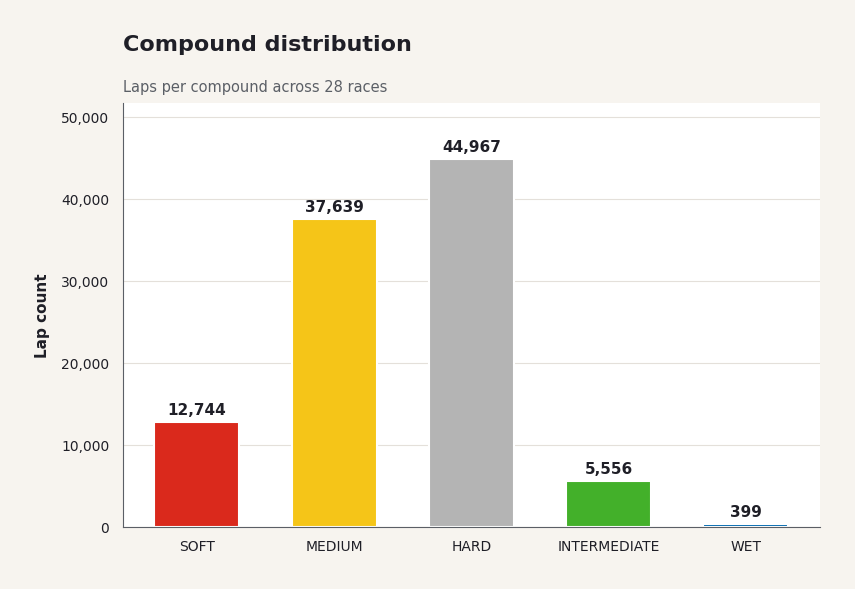

Insight: SOFT dominates with 12,744 laps (13% of all data); WET and INTERMEDIATE are rare. The model will learn dry-compound behaviour well; wet-compound predictions will be low-confidence due to scarcity.


In [7]:
comp_order = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]
present = [c for c in comp_order if c in df["Compound"].unique()]
counts_c = df["Compound"].value_counts().reindex(present)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(counts_c.index, counts_c.values,
              color=[COMPOUND_COLORS[c] for c in counts_c.index],
              edgecolor="white", linewidth=1.5, width=0.62)
for b, v in zip(bars, counts_c.values):
    ax.text(b.get_x() + b.get_width()/2, v + counts_c.max() * 0.012,
            f"{v:,}", ha="center", va="bottom",
            fontsize=11, fontweight="semibold", color=COLORS["charcoal"])

ax.set_title("Compound distribution")
add_subtitle(ax, f"Laps per compound across {df['Race'].nunique()} races")
ax.set_ylabel("Lap count")
ax.set_ylim(0, counts_c.max() * 1.15)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "compound_distribution.png"); plt.show()

top, top_n = counts_c.index[0], counts_c.iloc[0]
share = top_n / counts_c.sum()
print(f"Insight: {top} dominates with {top_n:,} laps ({share:.0%} of all data); "
      f"WET and INTERMEDIATE are rare. The model will learn dry-compound behaviour well; "
      f"wet-compound predictions will be low-confidence due to scarcity.")


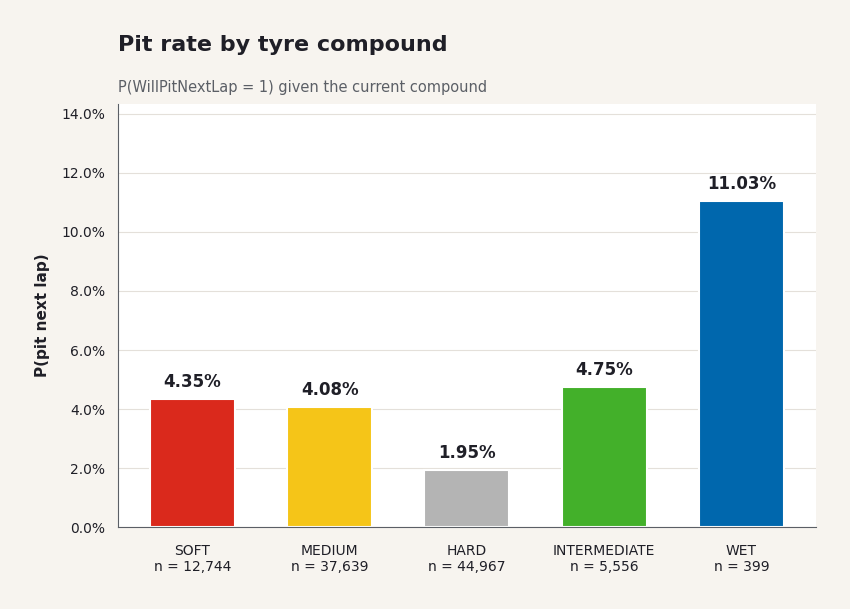

Insight: WET shows the highest per-lap pit probability (11.03%); softer compounds typically force earlier swaps. Compound is moderately useful on its own and should pair well with TyreLife as an interaction term.


In [8]:
g = (df.groupby("Compound")[TARGET]
        .agg(pit_rate="mean", laps="count")
        .reindex(present))

xlabels = [f"{c}\nn = {int(n):,}" for c, n in zip(g.index, g["laps"].values)]
values  = g["pit_rate"].values

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(range(len(g)), values,
              color=[COMPOUND_COLORS[c] for c in g.index],
              edgecolor="white", linewidth=1.5, width=0.62)
for i, v in enumerate(values):
    ax.text(i, v + values.max() * 0.025, f"{v:.2%}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=COLORS["charcoal"])

ax.set_title("Pit rate by tyre compound")
add_subtitle(ax, "P(WillPitNextLap = 1) given the current compound")
ax.set_xticks(range(len(g))); ax.set_xticklabels(xlabels)
ax.set_xlabel(""); ax.set_ylabel("P(pit next lap)")
ax.set_ylim(0, values.max() * 1.30)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
ax.tick_params(axis="x", pad=6)
fig.savefig(FIG_DIR / "pit_rate_by_compound.png"); plt.show()

top_c = g["pit_rate"].idxmax()
print(f"Insight: {top_c} shows the highest per-lap pit probability ({g.loc[top_c,'pit_rate']:.2%}); "
      f"softer compounds typically force earlier swaps. Compound is moderately useful on its own "
      f"and should pair well with TyreLife as an interaction term.")


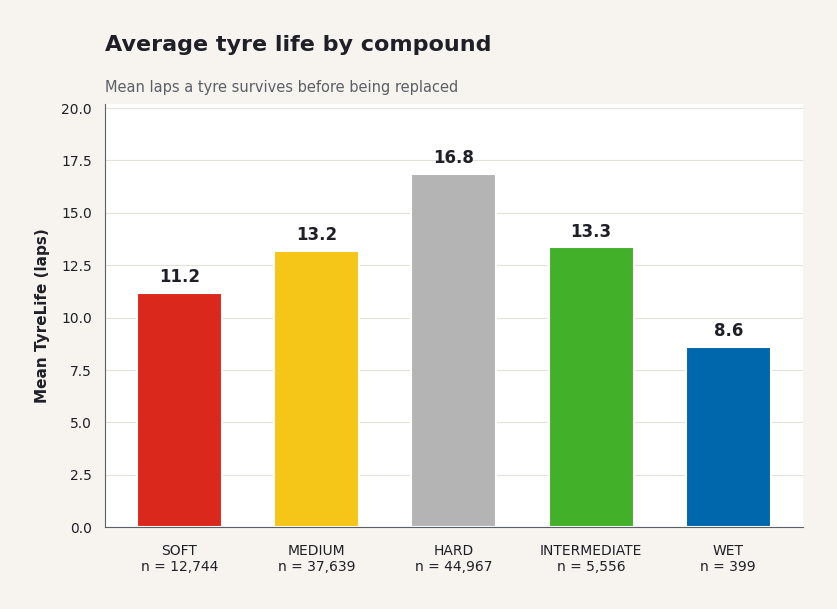

Insight: HARD averages the longest stint (16.8 laps) while WET averages 8.6. Mean tyre life per compound is consistent with real F1 tyre allocation rules — strategists pick harder compounds when they want to extend stints.


In [9]:
g = (df.groupby("Compound")["TyreLife"]
        .agg(mean_life="mean", median_life="median", laps="count")
        .reindex(present))
xlabels = [f"{c}\nn = {int(n):,}" for c, n in zip(g.index, g["laps"].values)]
values  = g["mean_life"].values

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(range(len(g)), values,
              color=[COMPOUND_COLORS[c] for c in g.index],
              edgecolor="white", linewidth=1.5, width=0.62)
for i, v in enumerate(values):
    ax.text(i, v + values.max() * 0.02, f"{v:.1f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=COLORS["charcoal"])

ax.set_title("Average tyre life by compound")
add_subtitle(ax, "Mean laps a tyre survives before being replaced")
ax.set_xticks(range(len(g))); ax.set_xticklabels(xlabels)
ax.set_xlabel(""); ax.set_ylabel("Mean TyreLife (laps)")
ax.set_ylim(0, values.max() * 1.20)
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
ax.tick_params(axis="x", pad=6)
fig.savefig(FIG_DIR / "average_tyre_life_by_compound.png"); plt.show()

longest = g["mean_life"].idxmax(); shortest = g["mean_life"].idxmin()
print(f"Insight: {longest} averages the longest stint ({g.loc[longest,'mean_life']:.1f} laps) "
      f"while {shortest} averages {g.loc[shortest,'mean_life']:.1f}. Mean tyre life per compound "
      f"is consistent with real F1 tyre allocation rules — strategists pick harder compounds "
      f"when they want to extend stints.")


## 5. Race Progress Analysis

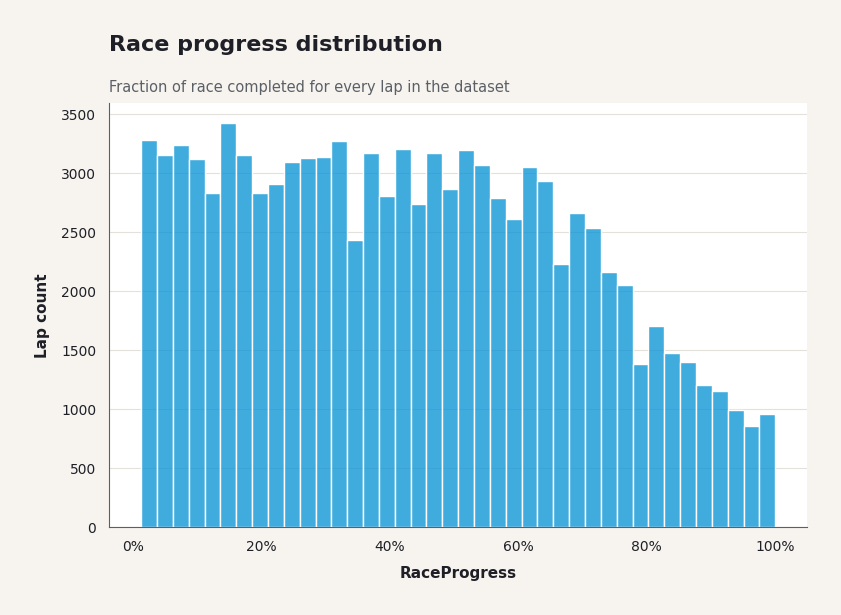

Insight: RaceProgress is roughly uniform — each fifth of the race contributes a similar number of laps, so any pit-rate variation across race-progress buckets reflects strategy, not sampling.


In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(df["RaceProgress"], bins=40, color=COLORS["accent"],
             edgecolor="white", ax=ax)
ax.set_title("Race progress distribution")
add_subtitle(ax, "Fraction of race completed for every lap in the dataset")
ax.set_xlabel("RaceProgress")
ax.set_ylabel("Lap count")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "race_progress_distribution.png"); plt.show()

print("Insight: RaceProgress is roughly uniform — each fifth of the race contributes a similar "
      "number of laps, so any pit-rate variation across race-progress buckets reflects strategy, "
      "not sampling.")


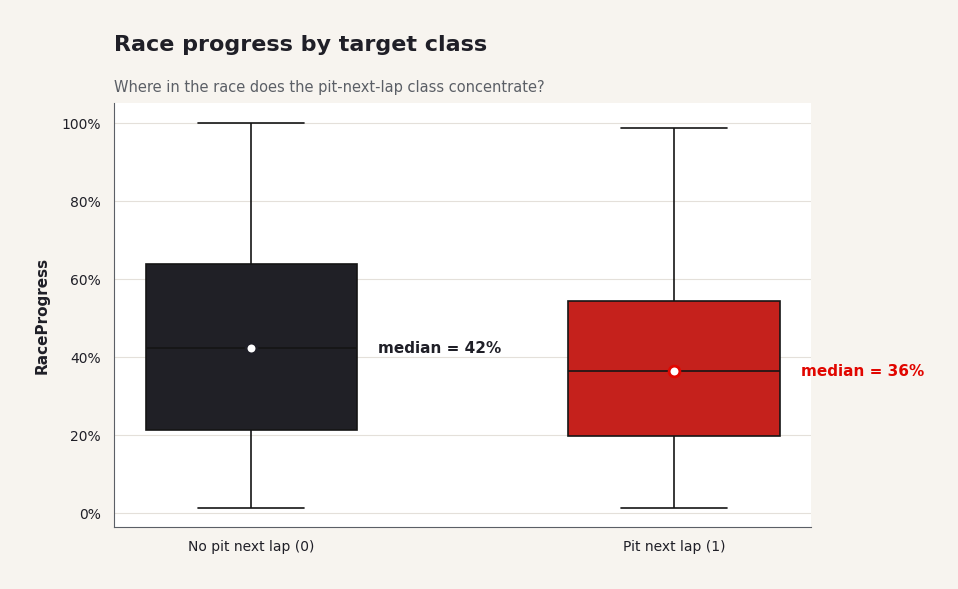

Insight: Median RaceProgress is 42% for class 0 and 36% for class 1. Pit decisions cluster around the mid-race window rather than the start or final laps.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x=TARGET, y="RaceProgress", hue=TARGET,
            palette=TARGET_PALETTE, legend=False,
            width=0.50, linewidth=1.2, fliersize=2.5, ax=ax)
medians = df.groupby(TARGET)["RaceProgress"].median()
for i, med in enumerate(medians.values):
    c = TARGET_PALETTE[i]
    ax.scatter([i], [med], s=60, color="white", edgecolor=c, linewidth=2.0, zorder=5)
    ax.text(i + 0.30, med, f"median = {med:.0%}",
            va="center", ha="left", fontsize=11, fontweight="bold", color=c)

ax.set_title("Race progress by target class")
add_subtitle(ax, "Where in the race does the pit-next-lap class concentrate?")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No pit next lap (0)", "Pit next lap (1)"])
ax.set_xlabel(""); ax.set_ylabel("RaceProgress")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "race_progress_by_target.png"); plt.show()

m0, m1 = medians.iloc[0], medians.iloc[1]
print(f"Insight: Median RaceProgress is {m0:.0%} for class 0 and {m1:.0%} for class 1. "
      f"Pit decisions cluster around the mid-race window rather than the start or final laps.")


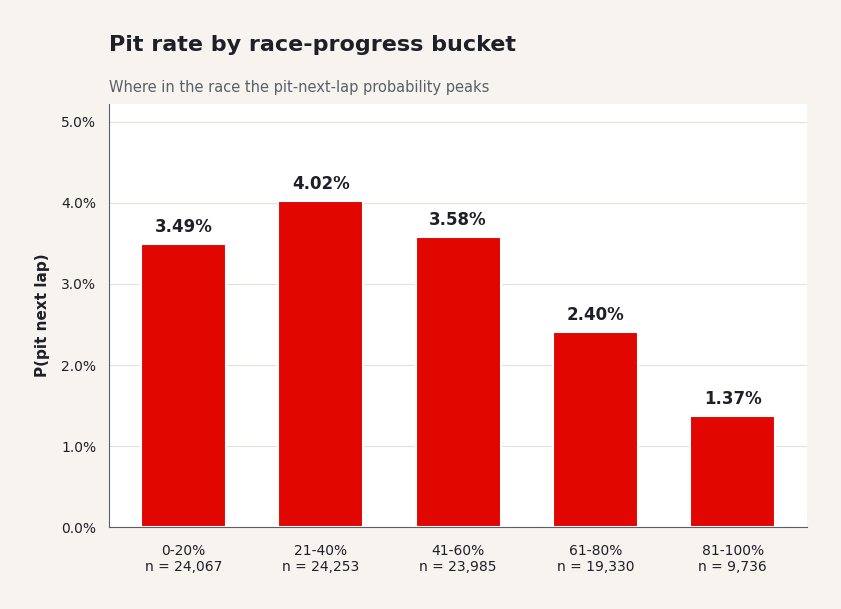

Insight: Pit rate peaks in the 21-40% window at 4.02%. Both the opening 20% and the final 20% show much lower pit probability — strategists avoid Lap-1 stops and rarely pit on the in-lap of the chequered flag.


In [12]:
bins = [0, .20, .40, .60, .80, 1.01]
labels = ["0-20%", "21-40%", "41-60%", "61-80%", "81-100%"]
buckets = pd.cut(df["RaceProgress"], bins=bins, labels=labels,
                 right=True, include_lowest=True)
g = df.groupby(buckets, observed=True)[TARGET].agg(["mean", "count"])

xlabels = [f"{lab}\nn = {n:,}" for lab, n in zip(g.index.astype(str), g["count"].values)]
values  = g["mean"].values

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(range(len(g)), values, color=COLORS["red"],
              edgecolor="white", linewidth=1.5, width=0.62)
for i, v in enumerate(values):
    ax.text(i, v + values.max() * 0.025, f"{v:.2%}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=COLORS["charcoal"])

ax.set_title("Pit rate by race-progress bucket")
add_subtitle(ax, "Where in the race the pit-next-lap probability peaks")
ax.set_xticks(range(len(g))); ax.set_xticklabels(xlabels)
ax.set_xlabel(""); ax.set_ylabel("P(pit next lap)")
ax.set_ylim(0, values.max() * 1.30)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
ax.tick_params(axis="x", pad=6)
fig.savefig(FIG_DIR / "pit_rate_by_race_progress_bucket.png"); plt.show()

peak_bucket = g["mean"].idxmax()
print(f"Insight: Pit rate peaks in the {peak_bucket} window at {g['mean'].max():.2%}. "
      f"Both the opening 20% and the final 20% show much lower pit probability — strategists "
      f"avoid Lap-1 stops and rarely pit on the in-lap of the chequered flag.")


## 6. Lap Time & Degradation Analysis

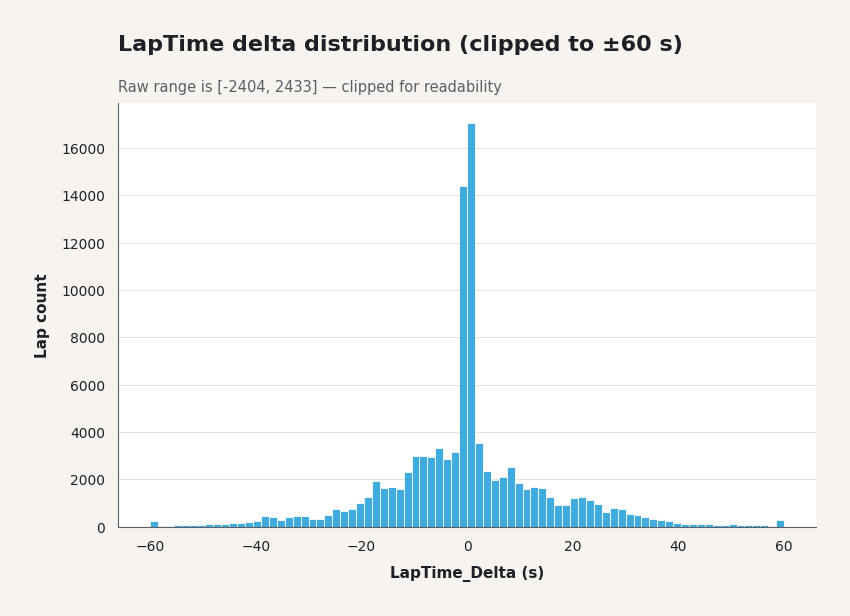

Insight: 45% of laps are within ±5 s of the previous lap; the long tails are red-flag, safety-car and pit-in/out laps. Modelling will benefit from clipping or robust-scaling LapTime_Delta to avoid those extremes dominating.


In [13]:
clipped = df["LapTime_Delta"].clip(-60, 60)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(clipped, bins=80, color=COLORS["accent"],
             edgecolor="white", ax=ax)
ax.set_title("LapTime delta distribution (clipped to ±60 s)")
add_subtitle(ax, f"Raw range is [{df['LapTime_Delta'].min():.0f}, {df['LapTime_Delta'].max():.0f}] — clipped for readability")
ax.set_xlabel("LapTime_Delta (s)")
ax.set_ylabel("Lap count")
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "lap_time_delta_distribution.png"); plt.show()

share_close = ((df["LapTime_Delta"].abs() <= 5)).mean()
print(f"Insight: {share_close:.0%} of laps are within ±5 s of the previous lap; "
      f"the long tails are red-flag, safety-car and pit-in/out laps. Modelling will benefit "
      f"from clipping or robust-scaling LapTime_Delta to avoid those extremes dominating.")


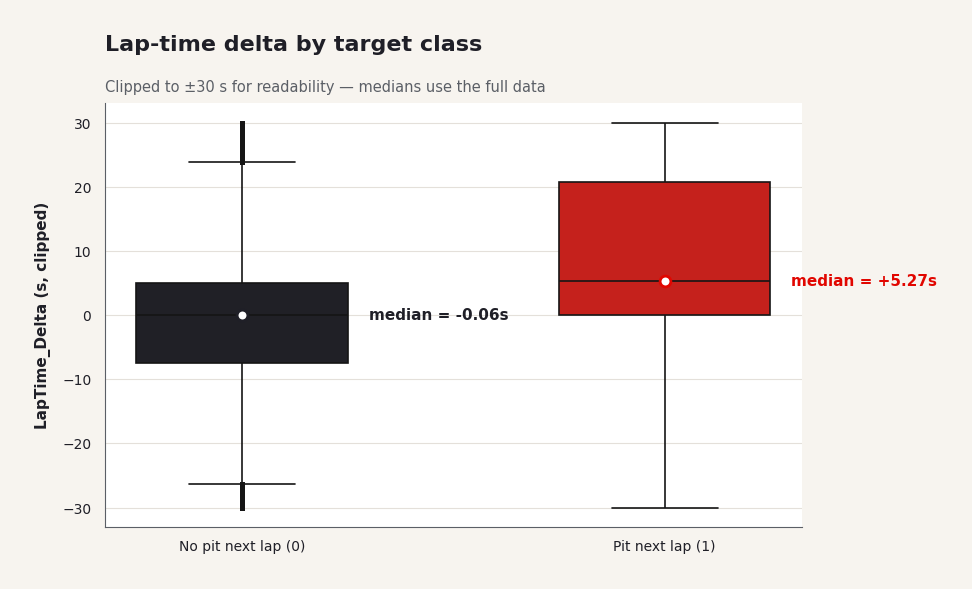

Insight: Median LapTime_Delta is -0.06 s for class 0 vs +5.27 s for class 1. The lap immediately before a pit is typically a slower, in-lap; that gap should help the model separate classes.


In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df.assign(LTD=df["LapTime_Delta"].clip(-30, 30)),
            x=TARGET, y="LTD", hue=TARGET,
            palette=TARGET_PALETTE, legend=False,
            width=0.50, linewidth=1.2, fliersize=2.5, ax=ax)
medians = df.groupby(TARGET)["LapTime_Delta"].median()
for i, med in enumerate(medians.values):
    c = TARGET_PALETTE[i]
    ax.scatter([i], [med], s=60, color="white", edgecolor=c, linewidth=2.0, zorder=5)
    ax.text(i + 0.30, med, f"median = {med:+.2f}s",
            va="center", ha="left", fontsize=11, fontweight="bold", color=c)

ax.set_title("Lap-time delta by target class")
add_subtitle(ax, "Clipped to ±30 s for readability — medians use the full data")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No pit next lap (0)", "Pit next lap (1)"])
ax.set_xlabel(""); ax.set_ylabel("LapTime_Delta (s, clipped)")
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "lap_time_delta_by_target.png"); plt.show()

m0, m1 = medians.iloc[0], medians.iloc[1]
print(f"Insight: Median LapTime_Delta is {m0:+.2f} s for class 0 vs {m1:+.2f} s for class 1. "
      f"The lap immediately before a pit is typically a slower, in-lap; that gap should help "
      f"the model separate classes.")


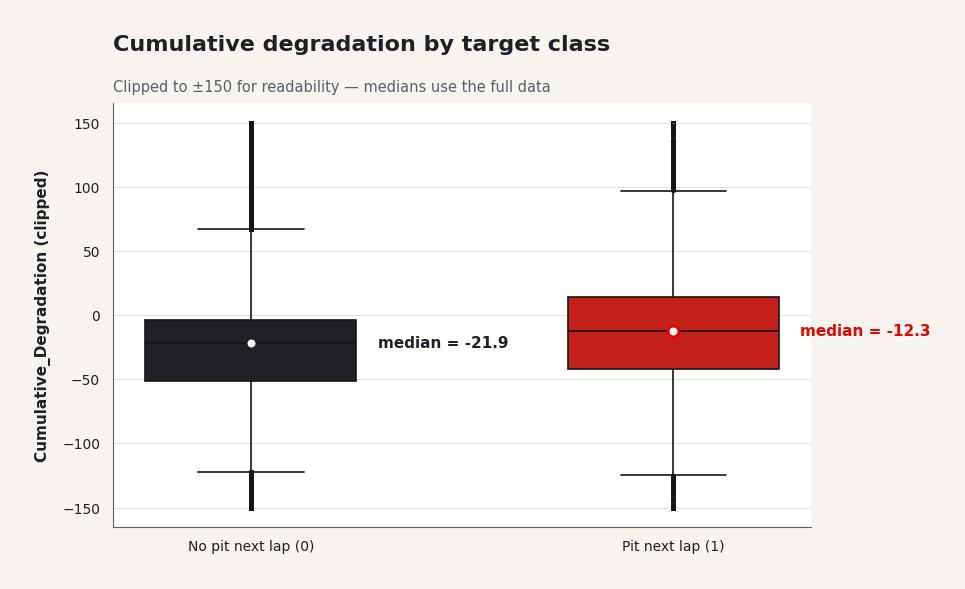

Insight: Median cumulative degradation is -21.9 for class 0 vs -12.3 for class 1. Higher degradation in the pre-pit class is consistent with strategists pitting once tyres stop performing.


In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df.assign(CD=df["Cumulative_Degradation"].clip(-150, 150)),
            x=TARGET, y="CD", hue=TARGET,
            palette=TARGET_PALETTE, legend=False,
            width=0.50, linewidth=1.2, fliersize=2.5, ax=ax)
medians = df.groupby(TARGET)["Cumulative_Degradation"].median()
for i, med in enumerate(medians.values):
    c = TARGET_PALETTE[i]
    ax.scatter([i], [med], s=60, color="white", edgecolor=c, linewidth=2.0, zorder=5)
    ax.text(i + 0.30, med, f"median = {med:+.1f}",
            va="center", ha="left", fontsize=11, fontweight="bold", color=c)

ax.set_title("Cumulative degradation by target class")
add_subtitle(ax, "Clipped to ±150 for readability — medians use the full data")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No pit next lap (0)", "Pit next lap (1)"])
ax.set_xlabel(""); ax.set_ylabel("Cumulative_Degradation (clipped)")
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "cumulative_degradation_by_target.png"); plt.show()

m0, m1 = medians.iloc[0], medians.iloc[1]
print(f"Insight: Median cumulative degradation is {m0:+.1f} for class 0 vs {m1:+.1f} for "
      f"class 1. {'Higher' if m1 > m0 else 'Lower'} degradation in the pre-pit class is "
      f"consistent with strategists pitting once tyres stop performing.")


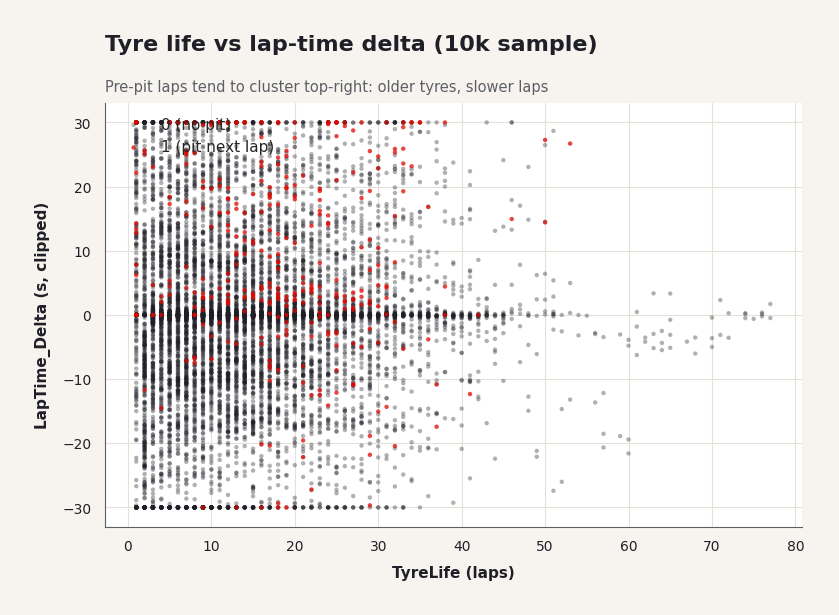

Insight: Class-1 points (red) drift toward the upper-right — older tyres combined with slower laps. This 2D structure suggests a non-linear model (tree-based) could pick up the interaction more easily than a linear classifier.


In [16]:
sample = df.sample(min(10_000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 5.5))
for cls in [0, 1]:
    s = sample[sample[TARGET] == cls]
    ax.scatter(s["TyreLife"], s["LapTime_Delta"].clip(-30, 30),
               s=10, alpha=0.35 if cls == 0 else 0.75,
               color=TARGET_PALETTE[cls],
               label=f"{cls} ({'pit next lap' if cls == 1 else 'no pit'})",
               edgecolor="none")
ax.set_title("Tyre life vs lap-time delta (10k sample)")
add_subtitle(ax, "Pre-pit laps tend to cluster top-right: older tyres, slower laps")
ax.set_xlabel("TyreLife (laps)")
ax.set_ylabel("LapTime_Delta (s, clipped)")
ax.legend(loc="upper left")
ax.yaxis.grid(True); ax.xaxis.grid(True); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "tyre_life_vs_lap_time_delta.png"); plt.show()

print("Insight: Class-1 points (red) drift toward the upper-right — older tyres combined with "
      "slower laps. This 2D structure suggests a non-linear model (tree-based) could pick up the "
      "interaction more easily than a linear classifier.")


## 7. Position & Race Situation Analysis

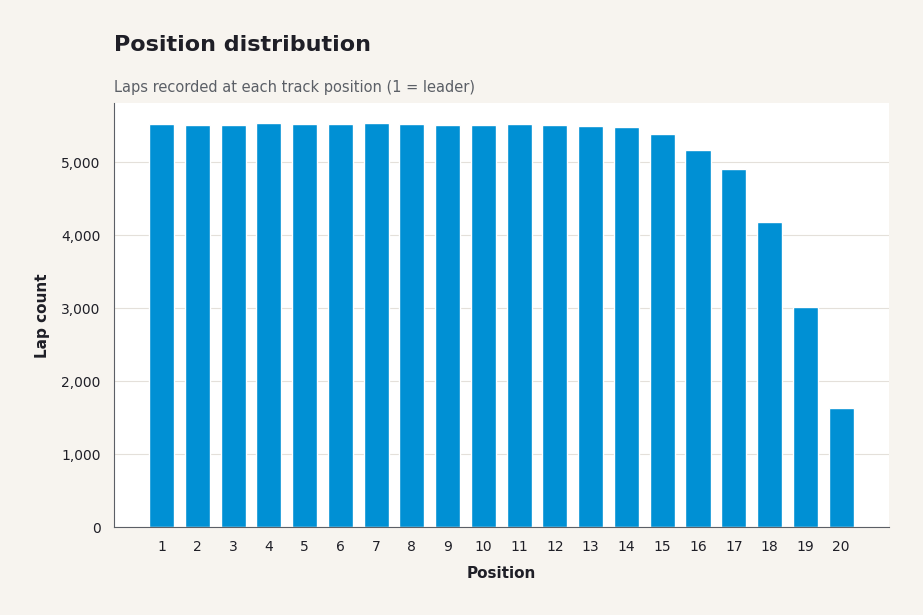

Insight: Position counts are relatively balanced across the grid, slightly thinner at the very back (cars retire mid-race). No position is dramatically over-represented, so position-based features won't be dominated by a single bucket.


In [17]:
counts_p = df["Position"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(counts_p.index, counts_p.values, color=COLORS["accent"],
       edgecolor="white", linewidth=1.0, width=0.7)
ax.set_title("Position distribution")
add_subtitle(ax, f"Laps recorded at each track position (1 = leader)")
ax.set_xlabel("Position")
ax.set_ylabel("Lap count")
ax.set_xticks(counts_p.index)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "position_distribution.png"); plt.show()

print(f"Insight: Position counts are relatively balanced across the grid, slightly thinner at "
      f"the very back (cars retire mid-race). No position is dramatically over-represented, so "
      f"position-based features won't be dominated by a single bucket.")


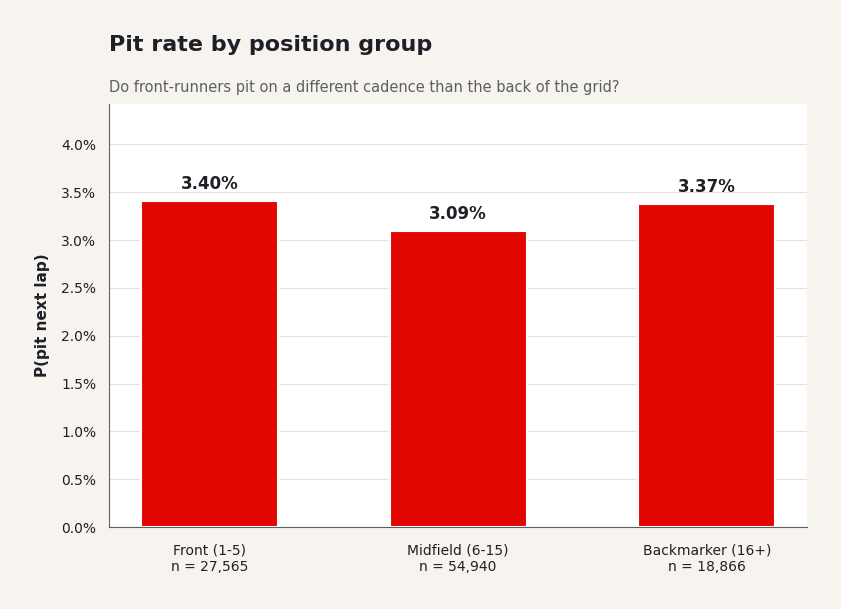

Insight: Front (1-5) pit most often (3.40%) and Midfield (6-15) least often (3.09%) — a spread of 0.31 percentage points. Position alone is a weak signal, but combined with tyre features it should help capture undercut/overcut strategy.


In [18]:
def grp(p):
    if p <= 5:  return "Front (1-5)"
    if p <= 15: return "Midfield (6-15)"
    return "Backmarker (16+)"

dfp = df.assign(PosGroup=df["Position"].map(grp))
order = ["Front (1-5)", "Midfield (6-15)", "Backmarker (16+)"]
g = dfp.groupby("PosGroup", observed=True)[TARGET].agg(["mean", "count"]).reindex(order)
xlabels = [f"{lab}\nn = {int(n):,}" for lab, n in zip(g.index, g["count"].values)]
values  = g["mean"].values

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(range(len(g)), values, color=COLORS["red"],
              edgecolor="white", linewidth=1.5, width=0.55)
for i, v in enumerate(values):
    ax.text(i, v + values.max() * 0.025, f"{v:.2%}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=COLORS["charcoal"])

ax.set_title("Pit rate by position group")
add_subtitle(ax, "Do front-runners pit on a different cadence than the back of the grid?")
ax.set_xticks(range(len(g))); ax.set_xticklabels(xlabels)
ax.set_xlabel(""); ax.set_ylabel("P(pit next lap)")
ax.set_ylim(0, values.max() * 1.30)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
ax.tick_params(axis="x", pad=6)
fig.savefig(FIG_DIR / "pit_rate_by_position_group.png"); plt.show()

top = g["mean"].idxmax(); bot = g["mean"].idxmin()
spread = (g["mean"].max() - g["mean"].min()) * 100
print(f"Insight: {top} pit most often ({g.loc[top,'mean']:.2%}) and {bot} least often "
      f"({g.loc[bot,'mean']:.2%}) — a spread of {spread:.2f} percentage points. Position alone "
      f"is a weak signal, but combined with tyre features it should help capture undercut/overcut strategy.")


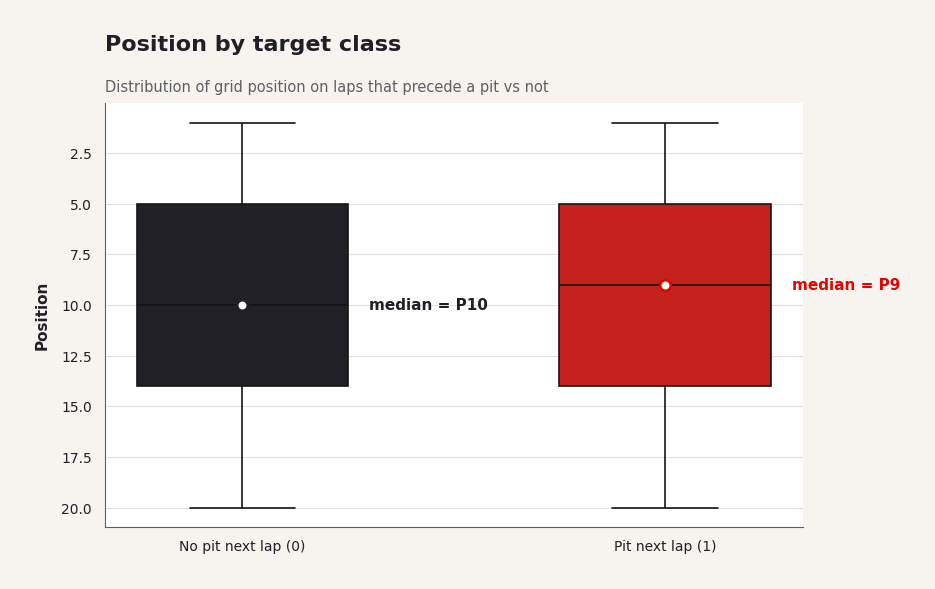

Insight: The two distributions overlap heavily — pre-pit laps come from every part of the grid. Position is not a stand-alone predictor and will only carry weight through interactions (e.g. midfield drivers undercutting from clean air).


In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x=TARGET, y="Position", hue=TARGET,
            palette=TARGET_PALETTE, legend=False,
            width=0.50, linewidth=1.2, fliersize=2.5, ax=ax)
medians = df.groupby(TARGET)["Position"].median()
for i, med in enumerate(medians.values):
    c = TARGET_PALETTE[i]
    ax.scatter([i], [med], s=60, color="white", edgecolor=c, linewidth=2.0, zorder=5)
    ax.text(i + 0.30, med, f"median = P{int(med)}",
            va="center", ha="left", fontsize=11, fontweight="bold", color=c)

ax.set_title("Position by target class")
add_subtitle(ax, "Distribution of grid position on laps that precede a pit vs not")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No pit next lap (0)", "Pit next lap (1)"])
ax.set_xlabel(""); ax.set_ylabel("Position")
ax.invert_yaxis()  # P1 at top
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "position_by_target.png"); plt.show()

print(f"Insight: The two distributions overlap heavily — pre-pit laps come from every part of "
      f"the grid. Position is not a stand-alone predictor and will only carry weight through "
      f"interactions (e.g. midfield drivers undercutting from clean air).")


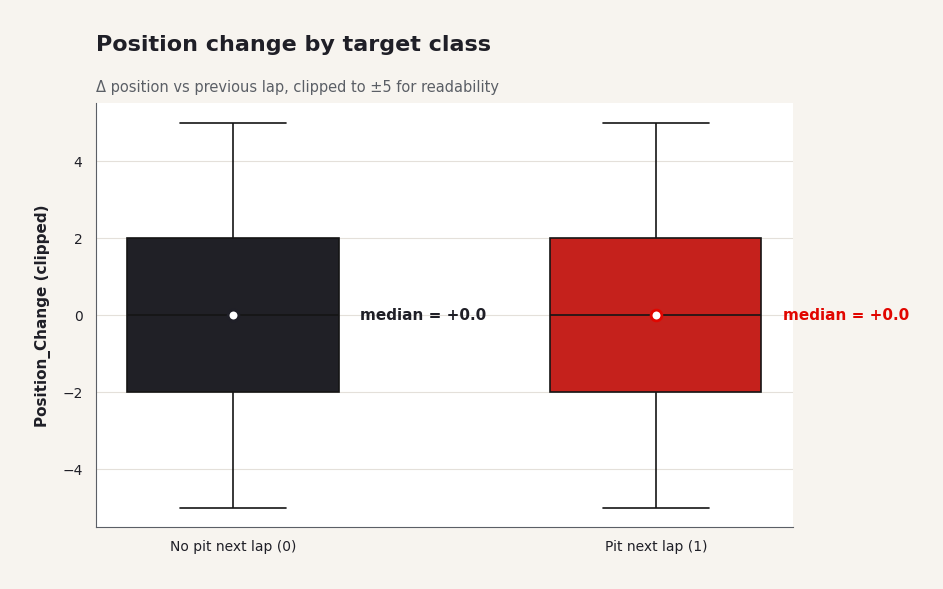

Insight: Median Position_Change sits near zero for both classes (+0.0 vs +0.0). The variable carries lap-to-lap noise but very little class signal on its own — useful as a secondary feature, not a primary one.


In [20]:
pc_clip = df["Position_Change"].clip(-5, 5)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df.assign(PC=pc_clip), x=TARGET, y="PC", hue=TARGET,
            palette=TARGET_PALETTE, legend=False,
            width=0.50, linewidth=1.2, fliersize=2.5, ax=ax)
medians = df.groupby(TARGET)["Position_Change"].median()
for i, med in enumerate(medians.values):
    c = TARGET_PALETTE[i]
    ax.scatter([i], [med], s=60, color="white", edgecolor=c, linewidth=2.0, zorder=5)
    ax.text(i + 0.30, med, f"median = {med:+.1f}",
            va="center", ha="left", fontsize=11, fontweight="bold", color=c)

ax.set_title("Position change by target class")
add_subtitle(ax, "Δ position vs previous lap, clipped to ±5 for readability")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No pit next lap (0)", "Pit next lap (1)"])
ax.set_xlabel(""); ax.set_ylabel("Position_Change (clipped)")
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "position_change_by_target.png"); plt.show()

m0, m1 = medians.iloc[0], medians.iloc[1]
print(f"Insight: Median Position_Change sits near zero for both classes ({m0:+.1f} vs {m1:+.1f}). "
      f"The variable carries lap-to-lap noise but very little class signal on its own — useful "
      f"as a secondary feature, not a primary one.")


## 8. Race & Driver Analysis

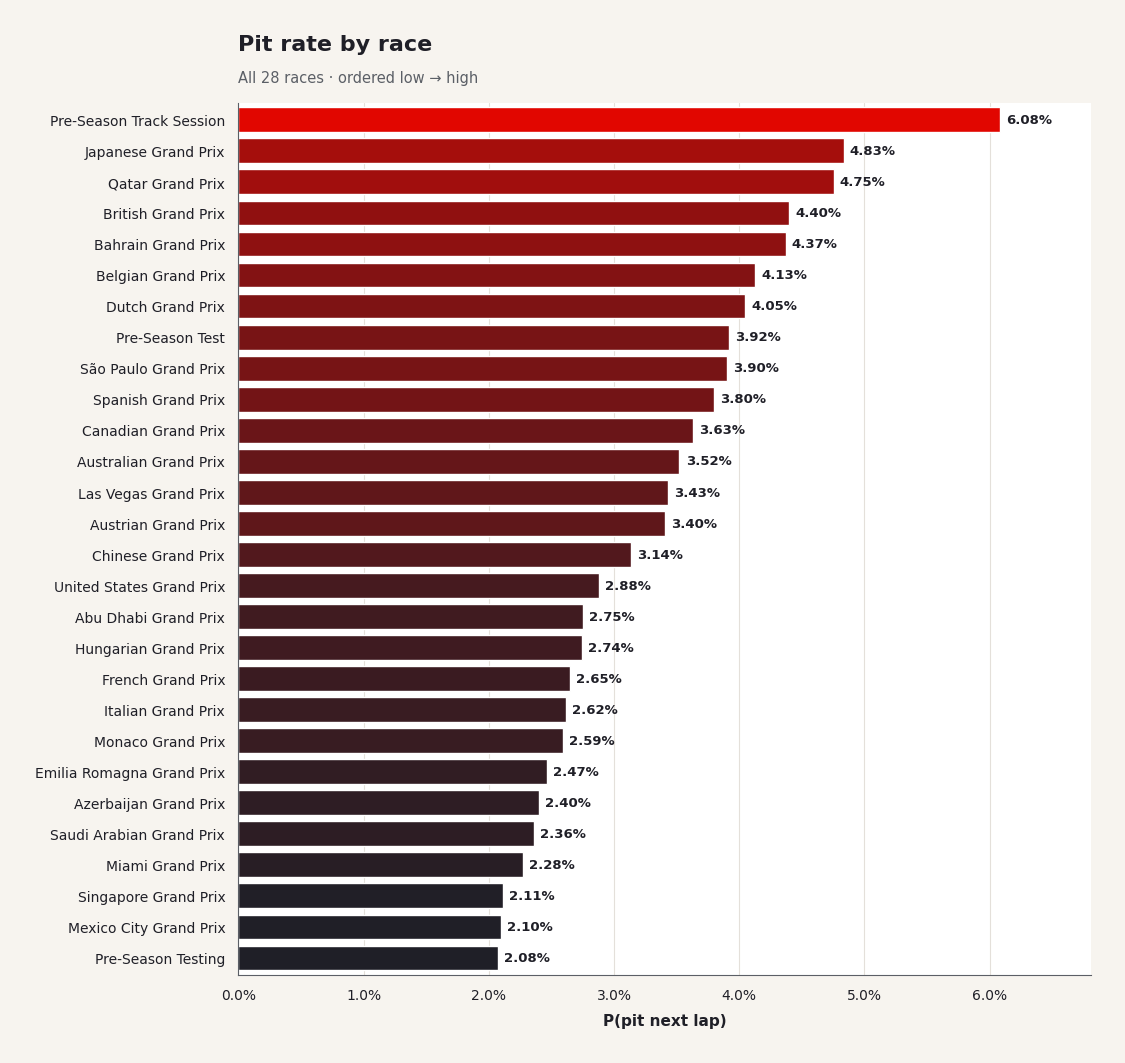

Insight: Pit rate varies meaningfully by race — 'Pre-Season Track Session' is highest (6.08%) and 'Pre-Season Testing' is lowest (2.08%). Track-specific strategy means the model will need GroupKFold on Race for honest cross-validation, otherwise it will memorise venues.


In [21]:
g = (df.groupby("Race")[TARGET]
        .agg(pit_rate="mean", laps="count")
        .sort_values("pit_rate", ascending=True))
values = g["pit_rate"].values
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "f1_reds", [COLORS["charcoal"], COLORS["red"]])
norm = mpl.colors.Normalize(values.min(), values.max())
colors = [cmap(norm(v)) for v in values]

fig, ax = plt.subplots(figsize=(11, 0.34 * len(g) + 1.8))
ax.barh(g.index, values, color=colors, edgecolor="white", linewidth=1.0)
for i, v in enumerate(values):
    ax.text(v + values.max() * 0.008, i, f"{v:.2%}",
            va="center", ha="left", fontsize=9.5,
            color=COLORS["charcoal"], fontweight="semibold")

ax.set_title("Pit rate by race")
add_subtitle(ax, f"All {len(g)} races · ordered low → high")
ax.set_xlabel("P(pit next lap)")
ax.set_xlim(0, values.max() * 1.12)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
ax.xaxis.grid(True); ax.yaxis.grid(False); ax.set_axisbelow(True)
ax.margins(y=0.005)
fig.savefig(FIG_DIR / "pit_rate_by_race.png"); plt.show()

hi, lo = g["pit_rate"].idxmax(), g["pit_rate"].idxmin()
print(f"Insight: Pit rate varies meaningfully by race — '{hi}' is highest ({g.loc[hi,'pit_rate']:.2%}) "
      f"and '{lo}' is lowest ({g.loc[lo,'pit_rate']:.2%}). Track-specific strategy means the model "
      f"will need GroupKFold on Race for honest cross-validation, otherwise it will memorise venues.")


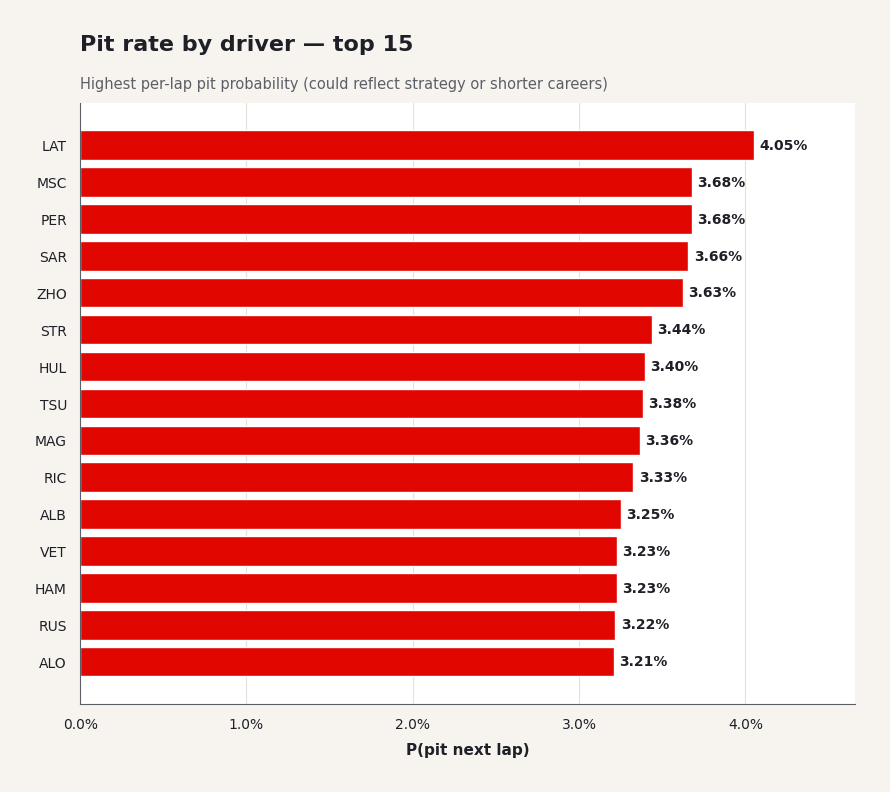

Insight: Chart capped at top 15 drivers for readability. High driver-level pit rates often reflect short careers (fewer total laps) or unusually aggressive teams; GroupKFold on Driver may also be worth considering depending on the modelling goal.


In [22]:
TOP_N = 15
g = (df.groupby("Driver")[TARGET]
        .agg(pit_rate="mean", laps="count")
        .sort_values("pit_rate", ascending=False)
        .head(TOP_N)
        .sort_values("pit_rate", ascending=True))
values = g["pit_rate"].values

fig, ax = plt.subplots(figsize=(10, 0.40 * len(g) + 1.8))
ax.barh(g.index, values, color=COLORS["red"], edgecolor="white", linewidth=1.0)
for i, v in enumerate(values):
    ax.text(v + values.max() * 0.008, i, f"{v:.2%}",
            va="center", ha="left", fontsize=10,
            color=COLORS["charcoal"], fontweight="semibold")

ax.set_title(f"Pit rate by driver — top {TOP_N}")
add_subtitle(ax, "Highest per-lap pit probability (could reflect strategy or shorter careers)")
ax.set_xlabel("P(pit next lap)")
ax.set_xlim(0, values.max() * 1.15)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
ax.xaxis.grid(True); ax.yaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "pit_rate_by_driver.png"); plt.show()

print(f"Insight: Chart capped at top {TOP_N} drivers for readability. High driver-level pit "
      f"rates often reflect short careers (fewer total laps) or unusually aggressive teams; "
      f"GroupKFold on Driver may also be worth considering depending on the modelling goal.")


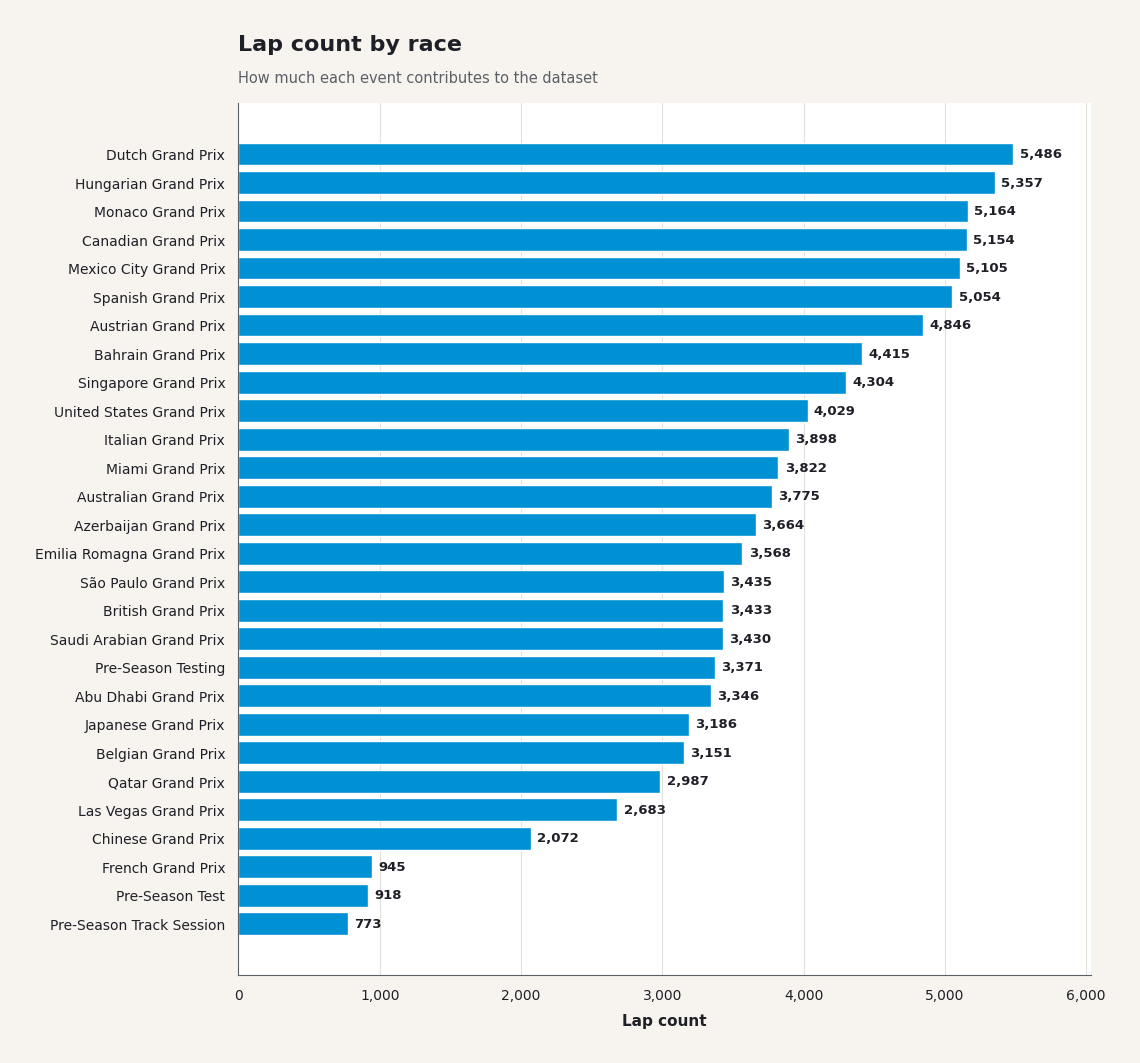

Insight: Lap counts vary from 773 (Pre-Season Track Session) to 5,486 (Dutch Grand Prix); some events are pre-season tests with reduced lap totals. A weighted aggregation by race could be considered if any analysis is sensitive to imbalanced contribution per event.


In [23]:
g = df.groupby("Race").size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 0.34 * len(g) + 1.8))
ax.barh(g.index, g.values, color=COLORS["accent"], edgecolor="white", linewidth=1.0)
for i, v in enumerate(g.values):
    ax.text(v + g.max() * 0.008, i, f"{v:,}",
            va="center", ha="left", fontsize=9.5,
            color=COLORS["charcoal"], fontweight="semibold")

ax.set_title("Lap count by race")
add_subtitle(ax, "How much each event contributes to the dataset")
ax.set_xlabel("Lap count")
ax.set_xlim(0, g.max() * 1.10)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.grid(True); ax.yaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "laps_by_race.png"); plt.show()

print(f"Insight: Lap counts vary from {g.min():,} ({g.idxmin()}) to {g.max():,} ({g.idxmax()}); "
      f"some events are pre-season tests with reduced lap totals. A weighted aggregation by race "
      f"could be considered if any analysis is sensitive to imbalanced contribution per event.")


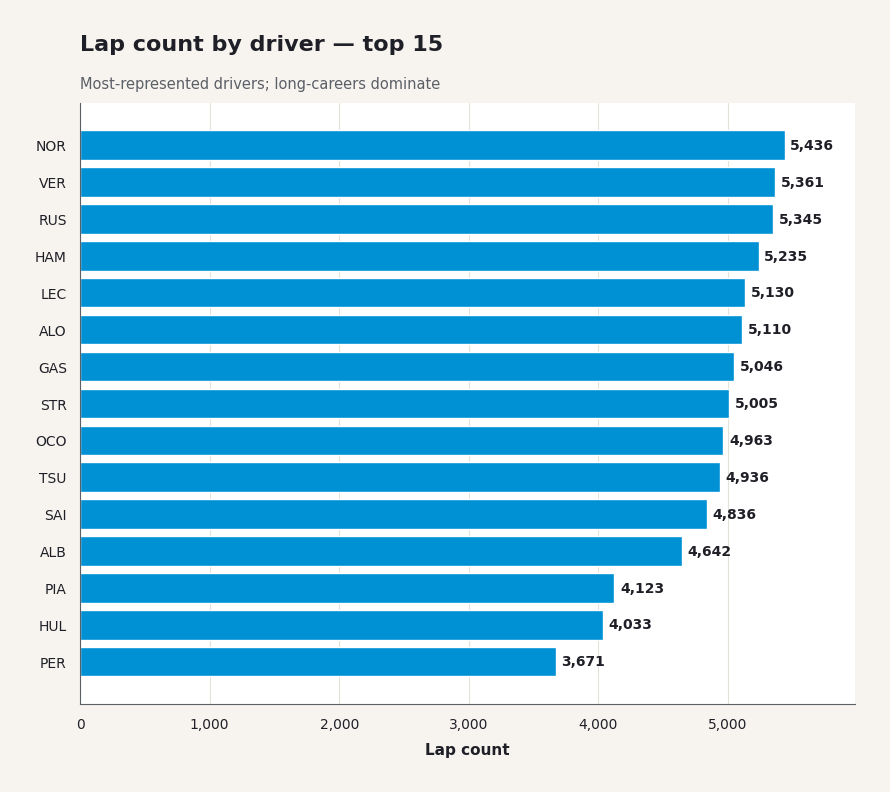

Insight: Chart capped at top 15. The most-frequent driver contributes 5,436 laps; drivers with few laps (rookies, reserve appearances) should be reviewed to decide whether to bucket them into 'OTHER' before encoding.


In [24]:
TOP_N = 15
g = df.groupby("Driver").size().sort_values(ascending=False).head(TOP_N).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 0.40 * len(g) + 1.8))
ax.barh(g.index, g.values, color=COLORS["accent"], edgecolor="white", linewidth=1.0)
for i, v in enumerate(g.values):
    ax.text(v + g.max() * 0.008, i, f"{v:,}",
            va="center", ha="left", fontsize=10,
            color=COLORS["charcoal"], fontweight="semibold")

ax.set_title(f"Lap count by driver — top {TOP_N}")
add_subtitle(ax, "Most-represented drivers; long-careers dominate")
ax.set_xlabel("Lap count")
ax.set_xlim(0, g.max() * 1.10)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.grid(True); ax.yaxis.grid(False); ax.set_axisbelow(True)
fig.savefig(FIG_DIR / "laps_by_driver.png"); plt.show()

print(f"Insight: Chart capped at top {TOP_N}. The most-frequent driver contributes "
      f"{g.max():,} laps; drivers with few laps (rookies, reserve appearances) should be reviewed "
      f"to decide whether to bucket them into 'OTHER' before encoding.")


## 9. Correlation & Feature Relationships

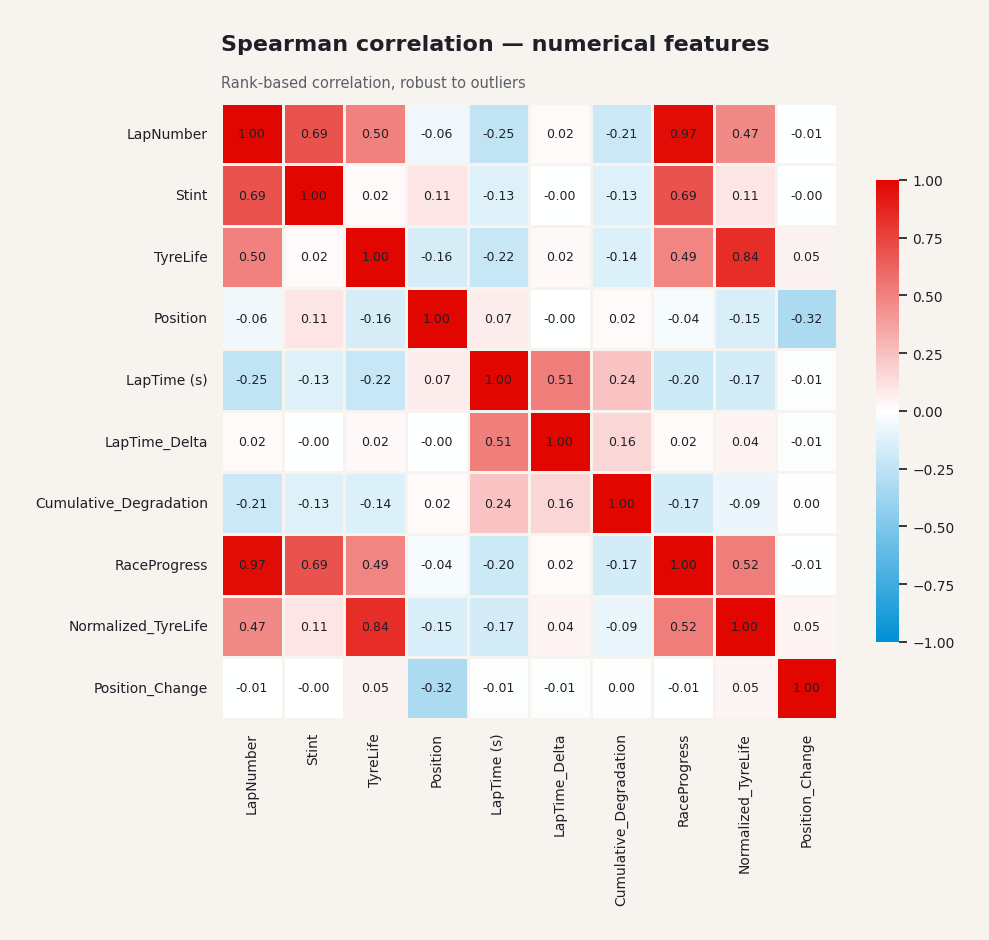

Insight: Strong intra-block correlations are expected — TyreLife ↔ Normalized_TyreLife, LapNumber ↔ RaceProgress, LapTime_Delta ↔ Cumulative_Degradation. Tree models handle redundant features fine; linear models will need dropping or regularisation.


In [25]:
NUM_COLS = ["LapNumber", "Stint", "TyreLife", "Position", "LapTime (s)",
            "LapTime_Delta", "Cumulative_Degradation", "RaceProgress",
            "Normalized_TyreLife", "Position_Change"]
corr = df[NUM_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "f1_div", [COLORS["accent"], "#FFFFFF", COLORS["red"]])
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, center=0,
            vmin=-1, vmax=1,
            linewidths=1.0, linecolor=COLORS["cream"], square=True,
            annot_kws={"fontsize": 9, "color": COLORS["charcoal"]},
            cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Spearman correlation — numerical features")
add_subtitle(ax, "Rank-based correlation, robust to outliers")
fig.savefig(FIG_DIR / "numerical_correlation_heatmap.png"); plt.show()

print("Insight: Strong intra-block correlations are expected — TyreLife ↔ Normalized_TyreLife, "
      "LapNumber ↔ RaceProgress, LapTime_Delta ↔ Cumulative_Degradation. Tree models handle "
      "redundant features fine; linear models will need dropping or regularisation.")


In [26]:
rows = []
for c in NUM_COLS:
    s_corr = df[[c, TARGET]].corr(method="spearman").iloc[0, 1]
    p_corr = df[[c, TARGET]].corr(method="pearson").iloc[0, 1]
    rows.append({"feature": c, "spearman_vs_target": s_corr, "pearson_vs_target": p_corr,
                 "abs_spearman": abs(s_corr)})
tgt_corr = (pd.DataFrame(rows)
              .sort_values("abs_spearman", ascending=False)
              .drop(columns="abs_spearman")
              .reset_index(drop=True))
out_csv = FIG_DIR / "target_correlation_table.csv"
tgt_corr.to_csv(out_csv, index=False)
print("Saved:", out_csv)
print()
print(tgt_corr.to_string(index=False))
print()
top = tgt_corr.iloc[0]
print(f"Insight: '{top['feature']}' has the highest |Spearman| with the target "
      f"({top['spearman_vs_target']:+.3f}). Absolute correlation values are low — which is "
      f"normal for a {df[TARGET].mean():.2%}-positive binary target — yet still meaningful at "
      f"this sample size (n = {len(df):,}). Correlation ≠ causation: ranking here suggests "
      f"which features may be informative, not which cause pit decisions.")


Saved: /Users/hiba/Documents/Projects/Experiments/Race Strategist/reports/figures/eda/target_correlation_table.csv

               feature  spearman_vs_target  pearson_vs_target
           LapTime (s)            0.124726           0.125106
         LapTime_Delta            0.121382           0.089906
   Normalized_TyreLife            0.116943           0.145073
                 Stint           -0.084486          -0.073650
              TyreLife            0.075020           0.069350
Cumulative_Degradation            0.055497           0.072335
             LapNumber           -0.036895          -0.037937
          RaceProgress           -0.035569          -0.037567
       Position_Change           -0.019339          -0.017333
              Position           -0.004136          -0.003801

Insight: 'LapTime (s)' has the highest |Spearman| with the target (+0.125). Absolute correlation values are low — which is normal for a 3.23%-positive binary target — yet still meaningful at this sampl

## 10. Data Quality Findings for Modeling

In [27]:
# Programmatic data-quality checklist for the upcoming modelling phase.
print("=== 1. Missing values ===")
miss = df.isna().sum(); miss = miss[miss > 0]
print(miss.to_string() if not miss.empty else "  none")
print()

print("=== 2. Outliers (|z| > 3) on key continuous features ===")
for c in ["LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "TyreLife"]:
    z = (df[c] - df[c].mean()) / df[c].std(ddof=0)
    share = (z.abs() > 3).mean()
    print(f"  {c:<25} extremes {share:.2%}  |  range "
          f"[{df[c].min():.2f}, {df[c].max():.2f}]")
print()

print("=== 3. Class imbalance ===")
pos, neg = int((df[TARGET] == 1).sum()), int((df[TARGET] == 0).sum())
print(f"  positives: {pos:,} ({pos/len(df):.2%})")
print(f"  negatives: {neg:,} ({neg/len(df):.2%})")
print(f"  ratio    : {neg/pos:.1f} : 1  → use stratified splits, PR-AUC / recall / F1, "
      f"consider class_weight='balanced' or SMOTE")
print()

print("=== 4. Categorical cardinality ===")
for c in ["Compound", "Year", "Race", "Driver"]:
    print(f"  {c:<10} nunique = {df[c].nunique():>3}  →  "
          f"{'one-hot' if df[c].nunique() <= 10 else 'target/frequency-encode or bucket rare values'}")
print()

print("=== 5. Leakage — must be EXCLUDED from X ===")
print(f"  {TARGET:<25} the target itself")
print(f"  {'PitNextLap':<25} known-bad audit target from Phase 2; carries label info")
print(f"  {'NextStint':<25} future stint value — used only to build WillPitNextLap")
print(f"  {'PitStop':<25} current-lap pit flag; perfectly co-located with pit events")
print()
print("  Note on PitStop: PitStop = 1 marks the lap a driver pits. WillPitNextLap")
print("  predicts the SAME pit one lap earlier. Using PitStop as a feature would")
print("  let the model see whether the pit is happening 'now', defeating the task.")
print("  Drop it entirely from X.")
print()

print("=== 6. Features to scale (continuous, wide range) ===")
print("  TyreLife, LapTime (s), LapTime_Delta, Cumulative_Degradation, Position_Change")
print("  Normalized_TyreLife and RaceProgress are already in [0, 1] — no scaling needed.")
print()

print("=== 7. Features to encode ===")
print("  Compound — one-hot (≤5 values)")
print("  Year     — one-hot (4 values) or treat as ordinal")
print("  Race, Driver — high cardinality: target-encode or bucket low-frequency values into 'OTHER'")

print()
print("Insight: The validated CSV is modelling-ready once the four leakage columns are "
      "dropped and the categorical columns are encoded. The dominant challenges for Phase 4 "
      "will be class imbalance handling and group-aware cross-validation (GroupKFold on Race).")


=== 1. Missing values ===
Compound       66
NextStint    1848

=== 2. Outliers (|z| > 3) on key continuous features ===
  LapTime (s)               extremes 0.04%  |  range [67.01, 2526.25]
  LapTime_Delta             extremes 0.03%  |  range [-2403.89, 2433.47]
  Cumulative_Degradation    extremes 0.47%  |  range [-274.56, 2412.43]
  TyreLife                  extremes 0.99%  |  range [1.00, 78.00]

=== 3. Class imbalance ===
  positives: 3,271 (3.23%)
  negatives: 98,100 (96.77%)
  ratio    : 30.0 : 1  → use stratified splits, PR-AUC / recall / F1, consider class_weight='balanced' or SMOTE

=== 4. Categorical cardinality ===
  Compound   nunique =   5  →  one-hot
  Year       nunique =   4  →  one-hot
  Race       nunique =  28  →  target/frequency-encode or bucket rare values
  Driver     nunique =  31  →  target/frequency-encode or bucket rare values

=== 5. Leakage — must be EXCLUDED from X ===
  WillPitNextLap            the target itself
  PitNextLap                known-bad audi